In [2]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

In [55]:
IMG_SIZE = 224
DATA_PATH = "../data/frames/train"  
NUM_SAMPLES = 3

In [45]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.8,
        contrast=0.8,
        saturation=0.8
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [46]:
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [47]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return tensor * std + mean

In [48]:
def get_random_images(data_path, num_samples=3):
    all_images = []

    for cls in os.listdir(data_path):
        class_path = os.path.join(data_path, cls)
        if not os.path.isdir(class_path):
            continue

        for video in os.listdir(class_path):
            video_path = os.path.join(class_path, video)
            if not os.path.isdir(video_path):
                continue

            for img in os.listdir(video_path):
                img_path = os.path.join(video_path, img)
                if os.path.isfile(img_path):
                    all_images.append(img_path)

    return random.sample(all_images, min(len(all_images), num_samples))

In [49]:
def show_transformations(image_path):
    img = Image.open(image_path).convert("RGB")

    transformed_imgs = [train_transform(img) for _ in range(4)]

    fig, axes = plt.subplots(1, 5, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i, t_img in enumerate(transformed_imgs):
        t_img = denormalize(t_img).permute(1,2,0).clamp(0,1)
        axes[i+1].imshow(t_img)
        axes[i+1].set_title(f"Augmented {i+1}")
        axes[i+1].axis("off")

    plt.show()

../data/frames/train/work/30686159780357336-WORK/frame_013.jpg


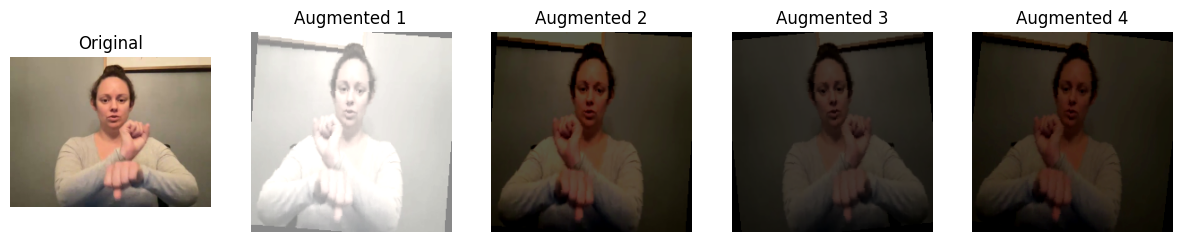

../data/frames/train/work/4499555412349274-WORK/frame_016.jpg


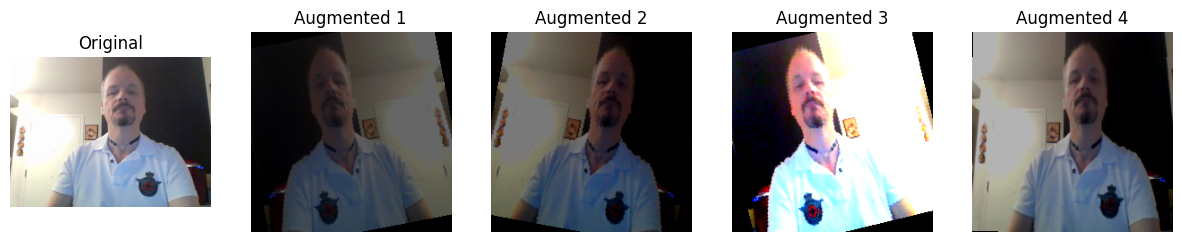

../data/frames/train/cheek/871492835507548-CHEEK/frame_014.jpg


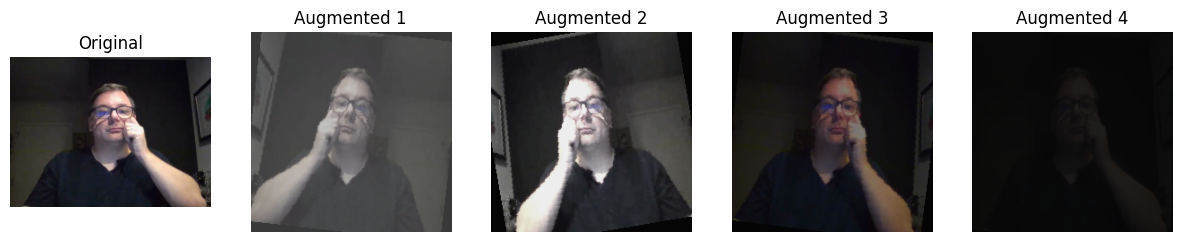

In [56]:
random_images = get_random_images(DATA_PATH, NUM_SAMPLES)

for img_path in random_images:
    print(img_path)
    show_transformations(img_path)

Vi använder data augmentation där varje bild slumpmässigt förändras under träning, vilket gör modellen mer robust och förbättrar generalisering.

In [63]:
step_transforms = [
    ("Resize", transforms.Resize((IMG_SIZE, IMG_SIZE))),
    ("Horizontal Flip", transforms.RandomHorizontalFlip(p=1.0)),
    ("Rotation", transforms.RandomRotation(15)),
    ("Color Jitter", transforms.ColorJitter(0.8,0.8,0.8)),
]

def show_step_by_step(image_path):
    img = Image.open(image_path).convert("RGB")

    fig, axes = plt.subplots(1, len(step_transforms)+1, figsize=(18,5))

    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    current_img = img

    for i, (name, transform) in enumerate(step_transforms):
        current_img = transform(current_img)
        axes[i+1].imshow(current_img)
        axes[i+1].set_title(name)
        axes[i+1].axis("off")

    plt.show()

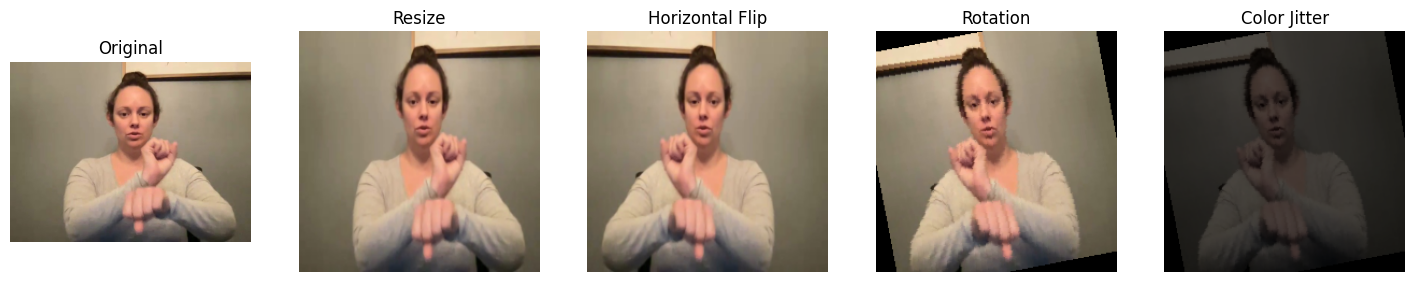

In [64]:
show_step_by_step(random_images[0])

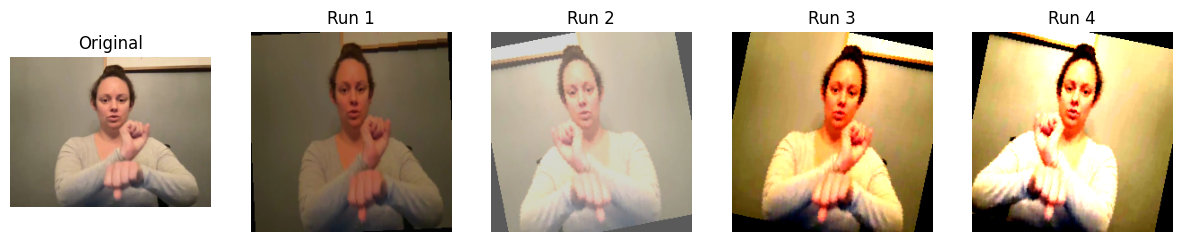

In [65]:
img = Image.open(random_images[0]).convert("RGB")

fig, axes = plt.subplots(1,5, figsize=(15,4))

axes[0].imshow(img)
axes[0].set_title("Original")

for i in range(4):
    aug = train_transform(img)
    aug = denormalize(aug).permute(1,2,0).clamp(0,1)
    axes[i+1].imshow(aug)
    axes[i+1].set_title(f"Run {i+1}")

for ax in axes:
    ax.axis("off")

plt.show()

In [66]:
model.eval()

# ta en sample
img_path = random_images[0]

img = Image.open(img_path).convert("RGB")
input_tensor = val_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    _, predicted = torch.max(output, 1)

print("Predicted class:", predicted.item())

plt.imshow(img)
plt.title(f"Prediction: {predicted.item()}")
plt.axis("off")

NameError: name 'model' is not defined